# 04 — Final Evaluation & Inference
## Aoranema Sentiment Analysis

Notebook ini melakukan evaluasi final terhadap dua model:

1. **TF-IDF + Logistic Regression** — baseline
2. **IndoBERT** — model Transformer hasil fine-tuning

Notebook ini **tidak melakukan training ulang**.

Input utama:
- `test_split.csv`
- folder `indobert_sentiment_model/`
- `baseline_tfidf_logreg.joblib`

Tujuan:
- evaluasi final pada test set yang sama,
- membandingkan kedua model secara adil,
- membuat confusion matrix dan classification report,
- melakukan error analysis,
- melakukan manual testing,
- menyiapkan fungsi inference final untuk integrasi Aoranema.

## Yang perlu ditambahkan ke Kaggle

Tambahkan sebagai **Input**:

### Dari Notebook 03 Revised
- `test_split.csv`
- folder `indobert_sentiment_model/`

### Dari Notebook 02
- `baseline_tfidf_logreg.joblib`

`sentiment_clean.csv` **tidak diperlukan lagi** pada Notebook 04 karena kita sudah memiliki test split final.

In [1]:
# ============================================================
# 0. INSTALL VERSI TRANSFORMERS YANG SAMA DENGAN NOTEBOOK 03
# ============================================================

import subprocess
import sys

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "transformers==4.46.3"
])

print("Transformers 4.46.3 siap digunakan.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 92.6 MB/s eta 0:00:00
Transformers 4.46.3 siap digunakan.


In [2]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from pathlib import Path
import json
import random

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

pd.set_option("display.max_colwidth", 180)

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

LABEL_ORDER = ["negative", "neutral", "positive"]

print("PyTorch      :", torch.__version__)
print("Transformers :", transformers.__version__)
print("CUDA tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))

assert transformers.__version__ == "4.46.3"

PyTorch      : 2.10.0+cu128
Transformers : 4.46.3
CUDA tersedia: True
GPU          : Tesla T4


In [3]:
# ============================================================
# 2. CARI SEMUA INPUT YANG DIBUTUHKAN
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input")

if not KAGGLE_INPUT.exists():
    raise FileNotFoundError("/kaggle/input tidak ditemukan.")

all_files = [
    path
    for path in KAGGLE_INPUT.rglob("*")
    if path.is_file()
]

print("Jumlah file dalam Kaggle Input:", len(all_files))

# ------------------------------------------------------------
# test_split.csv
# ------------------------------------------------------------

test_candidates = [
    path for path in all_files
    if path.name.lower() == "test_split.csv"
]

if not test_candidates:
    raise FileNotFoundError(
        "test_split.csv tidak ditemukan.\n"
        "Tambahkan output Notebook 03 Revised sebagai Input."
    )

TEST_PATH = test_candidates[0]

# ------------------------------------------------------------
# baseline_tfidf_logreg.joblib
# ------------------------------------------------------------

baseline_candidates = [
    path for path in all_files
    if path.name.lower() == "baseline_tfidf_logreg.joblib"
]

if not baseline_candidates:
    raise FileNotFoundError(
        "baseline_tfidf_logreg.joblib tidak ditemukan.\n"
        "Tambahkan output Notebook 02 sebagai Input."
    )

BASELINE_MODEL_PATH = baseline_candidates[0]

# ------------------------------------------------------------
# folder indobert_sentiment_model
# Cari config.json yang parent folder-nya bernama tepat
# indobert_sentiment_model
# ------------------------------------------------------------

indobert_config_candidates = [
    path for path in all_files
    if (
        path.name == "config.json"
        and path.parent.name == "indobert_sentiment_model"
    )
]

if not indobert_config_candidates:
    raise FileNotFoundError(
        "Folder indobert_sentiment_model tidak ditemukan.\n"
        "Tambahkan output Notebook 03 Revised sebagai Input."
    )

INDOBERT_MODEL_DIR = indobert_config_candidates[0].parent

print("\nInput yang digunakan:")
print("Test split     :", TEST_PATH)
print("Baseline model :", BASELINE_MODEL_PATH)
print("IndoBERT model :", INDOBERT_MODEL_DIR)

Jumlah file dalam Kaggle Input: 35

Input yang digunakan:
Test split     : /kaggle/input/notebooks/onallaaldeanuva/03-indobert-finetuning/test_split.csv
Baseline model : /kaggle/input/notebooks/onallaaldeanuva/02-baseline-tfidf-logreg/baseline_tfidf_logreg.joblib
IndoBERT model : /kaggle/input/notebooks/onallaaldeanuva/03-indobert-finetuning/indobert_sentiment_model


In [4]:
# ============================================================
# 3. LOAD TEST SET
# ============================================================

test_df = pd.read_csv(TEST_PATH)

required_columns = {"content", "sentiment"}

missing_columns = required_columns - set(test_df.columns)

if missing_columns:
    raise ValueError(
        f"Kolom test set tidak lengkap: {missing_columns}"
    )

assert test_df["content"].notna().all()
assert test_df["sentiment"].notna().all()
assert set(test_df["sentiment"].unique()).issubset(set(LABEL_ORDER))

print("Shape test set:", test_df.shape)

print("\nDistribusi test set:")
display(
    test_df["sentiment"]
    .value_counts()
    .reindex(LABEL_ORDER)
    .to_frame("count")
)

display(test_df.head())

Shape test set: (2159, 2)

Distribusi test set:


,count
sentiment,
negative,772
neutral,742
positive,645


,content,sentiment
0,sangat2 memuaskan bagi kami,positive
1,Aplikasinya bagus banget cuma pada saat mabar sering ngelag.. Tiba tinggal sendirian padahal masih di lokasi yg sama.. tolong di perbaiki,negative
2,Bagus permainannya seru tetapi menantang,positive
3,Tolong benerin nih bug keluar sendiri pas mau main kalo keluar terus gimana mainnya,neutral
4,Ini pinjaman bisa dicicil atau tidak,neutral


In [5]:
# ============================================================
# 4. PASTIKAN JUMLAH TEST SET SESUAI EKSPERIMEN
# ============================================================

EXPECTED_TEST_SIZE = 2159

assert len(test_df) == EXPECTED_TEST_SIZE, (
    f"Jumlah test set berubah. "
    f"Expected={EXPECTED_TEST_SIZE}, actual={len(test_df)}"
)

print("✓ Test set sesuai:", len(test_df), "data")

✓ Test set sesuai: 2159 data


# Bagian A — Evaluasi Baseline

In [6]:
# ============================================================
# 5. LOAD BASELINE TF-IDF + LOGISTIC REGRESSION
# ============================================================

baseline_model = joblib.load(
    BASELINE_MODEL_PATH
)

print("Baseline model berhasil di-load.")
print(baseline_model)

Baseline model berhasil di-load.
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=100000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('logreg', LogisticRegression(max_iter=1000, random_state=42))])


In [7]:
# ============================================================
# 6. PREDIKSI BASELINE PADA TEST SET
# ============================================================

X_test = test_df["content"].astype(str)
y_test = test_df["sentiment"].astype(str)

baseline_pred = baseline_model.predict(X_test)
baseline_prob = baseline_model.predict_proba(X_test)

print("Jumlah prediksi baseline:", len(baseline_pred))

Jumlah prediksi baseline: 2159


In [8]:
# ============================================================
# 7. FUNGSI EVALUASI
# ============================================================

def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=LABEL_ORDER,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": float(accuracy),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1)
    }


def print_metrics(model_name, metrics):
    print(f"=== {model_name} ===")

    for key, value in metrics.items():
        print(f"{key:16s}: {value:.4f}")

In [9]:
# ============================================================
# 8. METRIC BASELINE
# ============================================================

baseline_metrics = calculate_metrics(
    y_test,
    baseline_pred
)

print_metrics(
    "TF-IDF + LOGISTIC REGRESSION — TEST",
    baseline_metrics
)

=== TF-IDF + LOGISTIC REGRESSION — TEST ===
accuracy        : 0.7781
macro_precision : 0.7809
macro_recall    : 0.7767
macro_f1        : 0.7783


In [10]:
# ============================================================
# 9. CLASSIFICATION REPORT BASELINE
# ============================================================

baseline_report_dict = classification_report(
    y_test,
    baseline_pred,
    labels=LABEL_ORDER,
    digits=4,
    zero_division=0,
    output_dict=True
)

baseline_report_df = pd.DataFrame(
    baseline_report_dict
).transpose()

display(baseline_report_df)

,precision,recall,f1-score,support
negative,0.811083,0.834197,0.822478,772.000000
neutral,0.710183,0.733154,0.721485,742.000000
positive,0.821369,0.762791,0.790997,645.000000
accuracy,0.778138,0.778138,0.778138,0.778138
macro avg,0.780878,0.776714,0.778320,2159.000000
weighted avg,0.779479,0.778138,0.778364,2159.000000


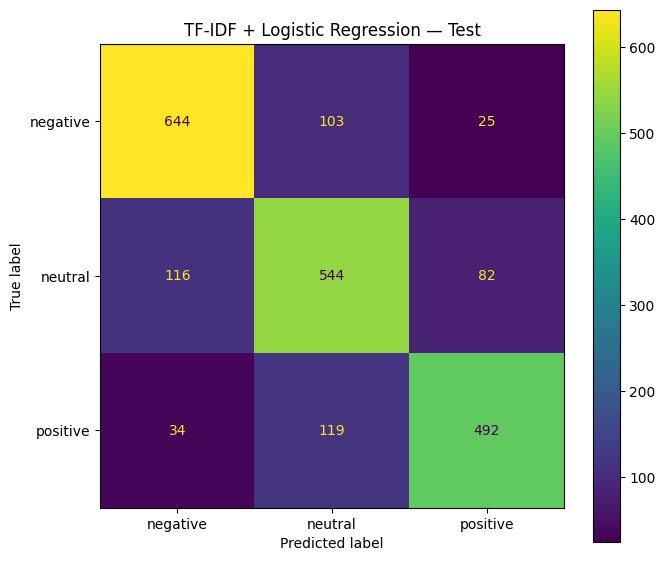

In [11]:
# ============================================================
# 10. CONFUSION MATRIX BASELINE
# ============================================================

baseline_cm = confusion_matrix(
    y_test,
    baseline_pred,
    labels=LABEL_ORDER
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=LABEL_ORDER
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("TF-IDF + Logistic Regression — Test")

plt.tight_layout()
plt.show()

# Bagian B — Evaluasi IndoBERT

In [12]:
# ============================================================
# 11. LOAD INDOBERT
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    INDOBERT_MODEL_DIR
)

indobert_model, loading_info = (
    AutoModelForSequenceClassification.from_pretrained(
        INDOBERT_MODEL_DIR,
        output_loading_info=True
    )
)

print("Missing keys   :", loading_info.get("missing_keys", []))
print("Unexpected keys:", loading_info.get("unexpected_keys", []))
print("Mismatched keys:", loading_info.get("mismatched_keys", []))

assert len(loading_info.get("missing_keys", [])) == 0
assert len(loading_info.get("unexpected_keys", [])) == 0
assert len(loading_info.get("mismatched_keys", [])) == 0

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

indobert_model = indobert_model.to(device)
indobert_model.eval()

print("\n✓ IndoBERT berhasil di-load.")
print("Device:", device)

Missing keys   : []
Unexpected keys: []
Mismatched keys: []

✓ IndoBERT berhasil di-load.
Device: cuda


In [13]:
# ============================================================
# 12. FUNGSI BATCH INFERENCE INDOBERT
# ============================================================

def predict_indobert(
    texts,
    model,
    tokenizer,
    batch_size=64,
    max_length=128
):
    all_predictions = []
    all_probabilities = []

    texts = list(texts)

    model.eval()

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[
            start:start + batch_size
        ]

        encoded = tokenizer(
            batch_texts,
            truncation=True,
            max_length=max_length,
            padding=True,
            return_tensors="pt"
        )

        encoded = {
            key: value.to(device)
            for key, value in encoded.items()
        }

        with torch.no_grad():
            outputs = model(**encoded)

        probabilities = torch.softmax(
            outputs.logits,
            dim=-1
        ).cpu().numpy()

        pred_ids = probabilities.argmax(
            axis=1
        )

        all_predictions.extend(pred_ids.tolist())
        all_probabilities.extend(probabilities.tolist())

    pred_labels = [
        model.config.id2label[int(pred_id)]
        for pred_id in all_predictions
    ]

    return (
        np.array(pred_labels),
        np.array(all_probabilities)
    )

In [14]:
# ============================================================
# 13. PREDIKSI INDOBERT PADA TEST SET
# ============================================================

indobert_pred, indobert_prob = predict_indobert(
    X_test.tolist(),
    indobert_model,
    tokenizer
)

print("Jumlah prediksi IndoBERT:", len(indobert_pred))

Jumlah prediksi IndoBERT: 2159


In [15]:
# ============================================================
# 14. METRIC INDOBERT
# ============================================================

indobert_metrics = calculate_metrics(
    y_test,
    indobert_pred
)

print_metrics(
    "INDOBERT — TEST",
    indobert_metrics
)

=== INDOBERT — TEST ===
accuracy        : 0.8106
macro_precision : 0.8161
macro_recall    : 0.8100
macro_f1        : 0.8122


In [16]:
# ============================================================
# 15. CLASSIFICATION REPORT INDOBERT
# ============================================================

indobert_report_dict = classification_report(
    y_test,
    indobert_pred,
    labels=LABEL_ORDER,
    digits=4,
    zero_division=0,
    output_dict=True
)

indobert_report_df = pd.DataFrame(
    indobert_report_dict
).transpose()

display(indobert_report_df)

,precision,recall,f1-score,support
negative,0.852048,0.835492,0.843689,772.00000
neutral,0.729763,0.789757,0.758576,742.00000
positive,0.866444,0.804651,0.834405,645.00000
accuracy,0.810560,0.810560,0.810560,0.81056
macro avg,0.816085,0.809967,0.812223,2159.00000
weighted avg,0.814322,0.810560,0.811664,2159.00000


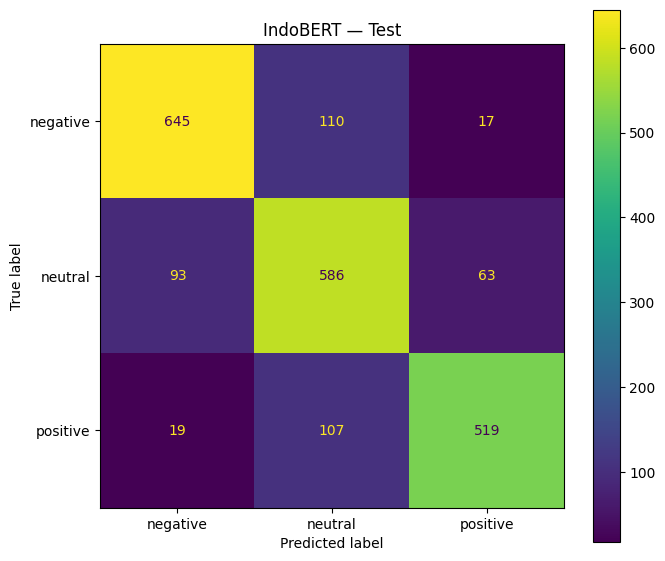

In [17]:
# ============================================================
# 16. CONFUSION MATRIX INDOBERT
# ============================================================

indobert_cm = confusion_matrix(
    y_test,
    indobert_pred,
    labels=LABEL_ORDER
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=indobert_cm,
    display_labels=LABEL_ORDER
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
ax.set_title("IndoBERT — Test")

plt.tight_layout()
plt.show()

# Bagian C — Perbandingan Final

In [18]:
# ============================================================
# 17. PERBANDINGAN METRIC FINAL
# ============================================================

comparison_df = pd.DataFrame({
    "TF-IDF + Logistic Regression": baseline_metrics,
    "IndoBERT": indobert_metrics
}).T

display(
    comparison_df.round(4)
)

macro_f1_difference = (
    indobert_metrics["macro_f1"]
    - baseline_metrics["macro_f1"]
)

accuracy_difference = (
    indobert_metrics["accuracy"]
    - baseline_metrics["accuracy"]
)

print(
    "Selisih Macro F1 IndoBERT - Baseline:",
    f"{macro_f1_difference:+.4f}"
)

print(
    "Selisih Accuracy IndoBERT - Baseline:",
    f"{accuracy_difference:+.4f}"
)

,accuracy,macro_precision,macro_recall,macro_f1
TF-IDF + Logistic Regression,0.7781,0.7809,0.7767,0.7783
IndoBERT,0.8106,0.8161,0.8100,0.8122


Selisih Macro F1 IndoBERT - Baseline: +0.0339
Selisih Accuracy IndoBERT - Baseline: +0.0324


In [19]:
# ============================================================
# 18. PERBANDINGAN F1 PER KELAS
# ============================================================

per_class_comparison = pd.DataFrame({
    "baseline_f1": [
        baseline_report_dict[label]["f1-score"]
        for label in LABEL_ORDER
    ],
    "indobert_f1": [
        indobert_report_dict[label]["f1-score"]
        for label in LABEL_ORDER
    ]
}, index=LABEL_ORDER)

per_class_comparison["difference"] = (
    per_class_comparison["indobert_f1"]
    - per_class_comparison["baseline_f1"]
)

display(
    per_class_comparison.round(4)
)

,baseline_f1,indobert_f1,difference
negative,0.8225,0.8437,0.0212
neutral,0.7215,0.7586,0.0371
positive,0.7910,0.8344,0.0434


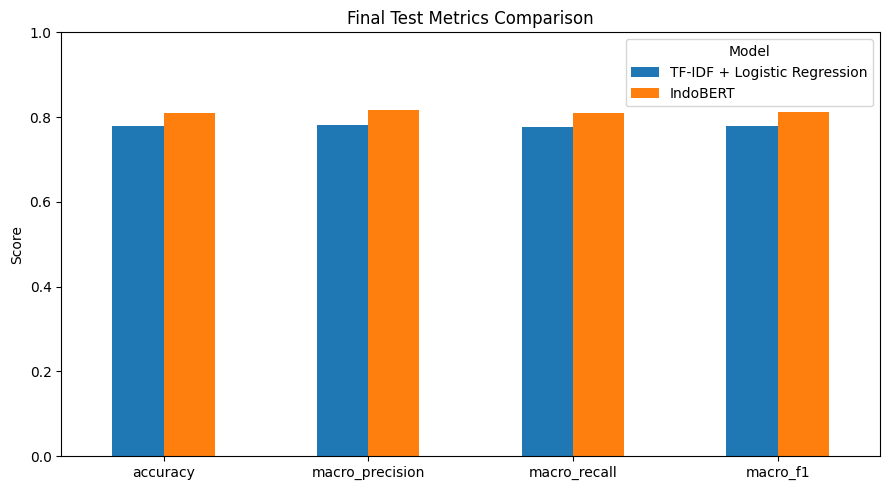

In [20]:
# ============================================================
# 19. GRAFIK PERBANDINGAN METRIC
# ============================================================

metrics_for_plot = comparison_df[
    [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1"
    ]
].T

ax = metrics_for_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Final Test Metrics Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="Model")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Bagian D — Error Analysis IndoBERT

In [21]:
# ============================================================
# 20. DATAFRAME HASIL PREDIKSI INDOBERT
# ============================================================

indobert_classes = [
    indobert_model.config.id2label[i]
    for i in range(indobert_model.config.num_labels)
]

indobert_confidence = indobert_prob.max(
    axis=1
)

result_df = pd.DataFrame({
    "content": X_test.values,
    "actual": y_test.values,
    "predicted": indobert_pred,
    "confidence": indobert_confidence
})

for i, label in enumerate(indobert_classes):
    result_df[f"{label}_prob"] = (
        indobert_prob[:, i]
    )

display(result_df.head())

,content,actual,predicted,confidence,negative_prob,neutral_prob,positive_prob
0,sangat2 memuaskan bagi kami,positive,positive,0.995928,0.000390,0.003682,0.995928
1,Aplikasinya bagus banget cuma pada saat mabar sering ngelag.. Tiba tinggal sendirian padahal masih di lokasi yg sama.. tolong di perbaiki,negative,negative,0.650759,0.650759,0.216411,0.132830
2,Bagus permainannya seru tetapi menantang,positive,positive,0.937446,0.002263,0.060291,0.937446
3,Tolong benerin nih bug keluar sendiri pas mau main kalo keluar terus gimana mainnya,neutral,negative,0.856337,0.856337,0.138848,0.004814
4,Ini pinjaman bisa dicicil atau tidak,neutral,neutral,0.905769,0.028986,0.905769,0.065245


In [22]:
# ============================================================
# 21. ERROR ANALYSIS
# ============================================================

errors_df = result_df[
    result_df["actual"]
    != result_df["predicted"]
].copy()

errors_df = errors_df.sort_values(
    "confidence",
    ascending=False
)

print("Total test data :", len(result_df))
print("Prediksi salah  :", len(errors_df))
print(
    "Error rate      :",
    f"{len(errors_df) / len(result_df) * 100:.2f}%"
)

display(errors_df.head(25))

Total test data : 2159
Prediksi salah  : 409
Error rate      : 18.94%


,content,actual,predicted,confidence,negative_prob,neutral_prob,positive_prob
1641,Izin uninstall Byee,neutral,negative,0.997534,0.997534,0.001164,0.001302
499,Apk ini tidak bagus jangan di download Tapi boong,positive,negative,0.996838,0.996838,0.001771,0.001391
1843,Ru coba,positive,neutral,0.993766,0.001961,0.993766,0.004272
2014,WAH GAME Nya BAGUS Banget kalian harus download kalo ga kalian nyesel deh,negative,positive,0.991071,0.001661,0.007268,0.991071
217,Pemburu clickbait!,neutral,negative,0.989130,0.989130,0.007086,0.003784
1768,setang,neutral,negative,0.989002,0.989002,0.009279,0.001719
1426,aplikasi ini cocok pacar saya aku belum punya pacar,neutral,positive,0.988939,0.002422,0.008639,0.988939
1646,Kk,positive,neutral,0.986779,0.003912,0.986779,0.009309
1288,Gg gimang,positive,neutral,0.985505,0.005543,0.985505,0.008952
999,Telek,negative,neutral,0.984715,0.003840,0.984715,0.011446


In [23]:
# ============================================================
# 22. ERROR DENGAN CONFIDENCE TINGGI
# ============================================================

high_conf_errors = errors_df[
    errors_df["confidence"] >= 0.90
]

print(
    "Error dengan confidence >= 0.90:",
    len(high_conf_errors)
)

display(high_conf_errors.head(25))

Error dengan confidence >= 0.90: 100


,content,actual,predicted,confidence,negative_prob,neutral_prob,positive_prob
1641,Izin uninstall Byee,neutral,negative,0.997534,0.997534,0.001164,0.001302
499,Apk ini tidak bagus jangan di download Tapi boong,positive,negative,0.996838,0.996838,0.001771,0.001391
1843,Ru coba,positive,neutral,0.993766,0.001961,0.993766,0.004272
2014,WAH GAME Nya BAGUS Banget kalian harus download kalo ga kalian nyesel deh,negative,positive,0.991071,0.001661,0.007268,0.991071
217,Pemburu clickbait!,neutral,negative,0.989130,0.989130,0.007086,0.003784
1768,setang,neutral,negative,0.989002,0.989002,0.009279,0.001719
1426,aplikasi ini cocok pacar saya aku belum punya pacar,neutral,positive,0.988939,0.002422,0.008639,0.988939
1646,Kk,positive,neutral,0.986779,0.003912,0.986779,0.009309
1288,Gg gimang,positive,neutral,0.985505,0.005543,0.985505,0.008952
999,Telek,negative,neutral,0.984715,0.003840,0.984715,0.011446


In [24]:
# ============================================================
# 23. POLA KESALAHAN ANTAR KELAS
# ============================================================

error_pattern = pd.crosstab(
    errors_df["actual"],
    errors_df["predicted"]
)

display(error_pattern)

predicted,negative,neutral,positive
actual,,,
negative,0,110,17
neutral,93,0,63
positive,19,107,0


# Bagian E — Manual Testing Aoranema

In [25]:
# ============================================================
# 24. FUNGSI INFERENCE SATU / BANYAK TEKS
# ============================================================

def predict_sentiment(
    text,
    model=indobert_model,
    tokenizer=tokenizer,
    max_length=128
):
    encoded = tokenizer(
        [text],
        truncation=True,
        max_length=max_length,
        padding=True,
        return_tensors="pt"
    )

    encoded = {
        key: value.to(device)
        for key, value in encoded.items()
    }

    model.eval()

    with torch.no_grad():
        outputs = model(**encoded)

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1
    )[0].cpu().numpy()

    pred_id = int(
        np.argmax(probabilities)
    )

    probabilities_by_label = {
        model.config.id2label[i]: float(probabilities[i])
        for i in range(len(probabilities))
    }

    return {
        "sentiment": model.config.id2label[pred_id],
        "confidence": float(probabilities[pred_id]),
        "probabilities": probabilities_by_label
    }

In [26]:
# ============================================================
# 25. MANUAL TEST
# ============================================================

manual_texts = [
    "Proses booking tiketnya cepat dan gampang banget.",
    "Pembayaran QRIS sering gagal dan bikin kesal.",
    "Aplikasinya biasa saja, sejauh ini tidak ada masalah.",
    "Customer service sangat ramah dan membantu.",
    "Aplikasinya lemot banget setelah update.",
    "Tempat bioskopnya nyaman dan petugasnya ramah.",
    "Pembayarannya berhasil, tetapi prosesnya cukup lama.",
    "Saya cuma ingin cek jadwal film untuk besok."
]

manual_results = []

for text in manual_texts:
    result = predict_sentiment(text)

    manual_results.append({
        "text": text,
        "sentiment": result["sentiment"],
        "confidence": result["confidence"],
        "negative_prob": result["probabilities"].get("negative", 0.0),
        "neutral_prob": result["probabilities"].get("neutral", 0.0),
        "positive_prob": result["probabilities"].get("positive", 0.0)
    })

manual_df = pd.DataFrame(
    manual_results
)

display(manual_df)

,text,sentiment,confidence,negative_prob,neutral_prob,positive_prob
0,Proses booking tiketnya cepat dan gampang banget.,neutral,0.629157,0.002105,0.629157,0.368737
1,Pembayaran QRIS sering gagal dan bikin kesal.,negative,0.997506,0.997506,0.001697,0.000797
2,"Aplikasinya biasa saja, sejauh ini tidak ada masalah.",neutral,0.464072,0.270547,0.464072,0.265381
3,Customer service sangat ramah dan membantu.,neutral,0.844766,0.006017,0.844766,0.149217
4,Aplikasinya lemot banget setelah update.,negative,0.978129,0.978129,0.018092,0.003779
5,Tempat bioskopnya nyaman dan petugasnya ramah.,positive,0.684601,0.004241,0.311158,0.684601
6,"Pembayarannya berhasil, tetapi prosesnya cukup lama.",neutral,0.867424,0.066853,0.867424,0.065723
7,Saya cuma ingin cek jadwal film untuk besok.,neutral,0.927094,0.054925,0.927094,0.017981


## Bentuk output untuk FastAPI

Untuk satu komentar:

```json
{
  "sentiment": "negative",
  "confidence": 0.94
}
```

Kategori seperti `booking`, `payment`, atau `customer_service` tetap dipilih oleh user/Laravel, bukan diprediksi oleh model.

Contoh alur:

```text
category = "payment"
comment  = "QRIS sering gagal."

        ↓

IndoBERT

        ↓

sentiment  = "negative"
confidence = 0.94
```

In [27]:
# ============================================================
# 26. CONTOH RESPONSE UNTUK AORANEMA
# ============================================================

example_category = "payment"
example_comment = "Pembayaran QRIS sering gagal."

prediction = predict_sentiment(
    example_comment
)

api_example = {
    "category": example_category,
    "comment": example_comment,
    "sentiment": prediction["sentiment"],
    "confidence": prediction["confidence"]
}

print(
    json.dumps(
        api_example,
        ensure_ascii=False,
        indent=2
    )
)

{
  "category": "payment",
  "comment": "Pembayaran QRIS sering gagal.",
  "sentiment": "negative",
  "confidence": 0.9833710193634033
}


# Bagian F — Simpan Hasil Final

In [28]:
# ============================================================
# 27. SIMPAN HASIL FINAL
# ============================================================

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_METRICS_PATH = (
    OUTPUT_DIR / "final_model_comparison.json"
)

INDOBERT_REPORT_PATH = (
    OUTPUT_DIR / "indobert_test_classification_report.csv"
)

BASELINE_REPORT_PATH = (
    OUTPUT_DIR / "baseline_test_classification_report_final.csv"
)

INDOBERT_PREDICTIONS_PATH = (
    OUTPUT_DIR / "indobert_test_predictions.csv"
)

ERRORS_PATH = (
    OUTPUT_DIR / "indobert_test_errors.csv"
)

MANUAL_PATH = (
    OUTPUT_DIR / "final_manual_predictions.csv"
)

PER_CLASS_PATH = (
    OUTPUT_DIR / "final_per_class_comparison.csv"
)

final_metrics = {
    "test_size": int(len(test_df)),
    "baseline": baseline_metrics,
    "indobert": indobert_metrics,
    "difference_indobert_minus_baseline": {
        "accuracy": float(accuracy_difference),
        "macro_f1": float(macro_f1_difference)
    }
}

with open(
    FINAL_METRICS_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        final_metrics,
        f,
        ensure_ascii=False,
        indent=2
    )

indobert_report_df.to_csv(
    INDOBERT_REPORT_PATH,
    index=True
)

baseline_report_df.to_csv(
    BASELINE_REPORT_PATH,
    index=True
)

result_df.to_csv(
    INDOBERT_PREDICTIONS_PATH,
    index=False
)

errors_df.to_csv(
    ERRORS_PATH,
    index=False
)

manual_df.to_csv(
    MANUAL_PATH,
    index=False
)

per_class_comparison.to_csv(
    PER_CLASS_PATH,
    index=True
)

print("Final metrics :", FINAL_METRICS_PATH)
print("IndoBERT report:", INDOBERT_REPORT_PATH)
print("Baseline report:", BASELINE_REPORT_PATH)
print("Predictions    :", INDOBERT_PREDICTIONS_PATH)
print("Errors         :", ERRORS_PATH)
print("Manual test    :", MANUAL_PATH)
print("Per-class      :", PER_CLASS_PATH)

Final metrics : /kaggle/working/final_model_comparison.json
IndoBERT report: /kaggle/working/indobert_test_classification_report.csv
Baseline report: /kaggle/working/baseline_test_classification_report_final.csv
Predictions    : /kaggle/working/indobert_test_predictions.csv
Errors         : /kaggle/working/indobert_test_errors.csv
Manual test    : /kaggle/working/final_manual_predictions.csv
Per-class      : /kaggle/working/final_per_class_comparison.csv


In [29]:
# ============================================================
# 28. RINGKASAN FINAL
# ============================================================

print("=" * 65)
print("FINAL EVALUATION — AORANEMA SENTIMENT ANALYSIS")
print("=" * 65)

print("\nTF-IDF + Logistic Regression")
print(
    f"Accuracy : {baseline_metrics['accuracy']:.4f}"
)
print(
    f"Macro F1 : {baseline_metrics['macro_f1']:.4f}"
)

print("\nIndoBERT")
print(
    f"Accuracy : {indobert_metrics['accuracy']:.4f}"
)
print(
    f"Macro F1 : {indobert_metrics['macro_f1']:.4f}"
)

print("\nDifference (IndoBERT - Baseline)")
print(
    f"Accuracy : {accuracy_difference:+.4f}"
)
print(
    f"Macro F1 : {macro_f1_difference:+.4f}"
)

print("\nSemua evaluasi dilakukan pada test set yang sama:")
print("Jumlah data:", len(test_df))

FINAL EVALUATION — AORANEMA SENTIMENT ANALYSIS

TF-IDF + Logistic Regression
Accuracy : 0.7781
Macro F1 : 0.7783

IndoBERT
Accuracy : 0.8106
Macro F1 : 0.8122

Difference (IndoBERT - Baseline)
Accuracy : +0.0324
Macro F1 : +0.0339

Semua evaluasi dilakukan pada test set yang sama:
Jumlah data: 2159


# Selesai

Setelah notebook selesai, simpan output berikut:

```text
final_model_comparison.json
indobert_test_classification_report.csv
baseline_test_classification_report_final.csv
indobert_test_predictions.csv
indobert_test_errors.csv
final_manual_predictions.csv
final_per_class_comparison.csv
```

Folder `indobert_sentiment_model/` dari Notebook 03 tetap merupakan artifact model utama untuk integrasi aplikasi.